# DL Training Pipeline: Deep Learning Model for lgCL Prediction

## Quick Start Guide

This notebook provides a simplified workflow for training a deep learning model to predict log clearance (lgCL) values from molecular structures using the AttentiveFP architecture.

### Overview
1. **Setup & Imports** - Load required libraries and configuration
2. **Load & Prepare Data** - Load raw data and canonicalize SMILES strings
3. **Feature Extraction** - Generate or load molecular features from AttentiveFP
4. **Data Splitting** - K-fold cross-validation split
5. **Model Initialize** - Create AttentiveFP model with optimizer and loss function
6. **Training Loop** - Train with early stopping and validation monitoring
7. **Evaluation** - Compute metrics on train/validation/test sets
8. **Visualization** - Generate performance plots and save predictions
9. **Embeddings** - Optional: extract learned embeddings from trained model

### Configuration
All hyperparameters are defined in `config.py`. Key parameters:
- **Model**: fingerprint_dim=100, attention layers (T=4)
- **Training**: batch_size=100, epochs=100, k-fold=5
- **Optimization**: learning_rate, weight_decay, MSE loss
- **Early Stopping**: patience=50, RMSE threshold=0.65

In [1]:
# ============================================================================
# SETUP & IMPORTS
# ============================================================================

import os
import sys
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Import config and utilities
from config import TRAINING, MODEL, OPTIM, EARLY_STOPPING, TIMESTAMP, get_output_dirs
from utils import (
    setup_seed, 
    create_directories, 
    load_raw_data, 
    filter_valid_molecules, 
    split_k_fold_data,
    compute_metrics
)
from AttentiveFP import Fingerprint  # Main model class

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# ============================================================================
# REPRODUCIBILITY AND DIRECTORIES
# ============================================================================

print("="*80)
print(f"DL Training Pipeline - Timestamp: {TIMESTAMP}")
print("="*80)

# Setup seed for reproducibility
setup_seed(TRAINING['seed'])
print(f"✓ Random seed set to {TRAINING['seed']}")

# Create output directories
output_dirs = get_output_dirs()
create_directories(output_dirs)

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Device: {device}")
print(f"  Config: fold_id={TRAINING['fold_id']}, k_fold={TRAINING['k_fold']}, batch_size={TRAINING['batch_size']}")

DL Training Pipeline - Timestamp: Thu_Apr__09_13-37-44_2026
✓ Random seed set to 8
✓ Directory ready: lgCL/cv_5_fold
✓ Directory ready: lgCL/cv_5_fold/fold_1
✓ Directory ready: lgCL/cv_5_fold/fold_1/saved_lgCL_mods
✓ Directory ready: lgCL/cv_5_fold/fold_1/results
✓ Directory ready: lgCL/cv_5_fold/fold_1/embeddings
✓ Device: cuda
  Config: fold_id=1, k_fold=5, batch_size=100


## Load & Prepare Data

In [ ]:
# ============================================================================
# LOAD RAW DATA
# ============================================================================

# Load raw CSV data
csv_path = TRAINING.get('data_path', 'data_prep/df_feature_5620.csv')
df_raw = load_raw_data(csv_path, tag_col='tag', task_col='lgCL')

print(f"\nData Summary:")
print(f"  Shape: {df_raw.shape}")
print(f"  Columns: {list(df_raw.columns[:10])}...")
print(f"  Column dtypes: {df_raw.dtypes.value_counts().to_dict()}")

# ============================================================================
# CANONICALIZE SMILES (if needed)
# ============================================================================

# Assuming 'SMILES' column exists; create canonical version if not present
if 'cano_smiles' not in df_raw.columns:
    # If original SMILES column exists, canonicalize it
    from rdkit import Chem
    df_raw['cano_smiles'] = df_raw['SMILES'].apply(
        lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x)) if pd.notna(x) else None
    )
    print(f"✓ Canonicalized SMILES strings")
else:
    print(f"✓ Canonical SMILES already present")

# ============================================================================
# LOAD OR GENERATE MOLECULAR FEATURES
# ============================================================================

# Try to load cached features
feature_cache_path = 'data_prep/df_feature_cached.pickle'
if os.path.exists(feature_cache_path):
    with open(feature_cache_path, 'rb') as f:
        feature_dicts = pickle.load(f)
    print(f"✓ Loaded cached features from {feature_cache_path}")
else:
    # Generate features using AttentiveFP Featurizer
    from AttentiveFP import Featurizer
    
    featurizer = Featurizer()
    feature_dicts = featurizer.get_features(df_raw['cano_smiles'].drop_duplicates().tolist())
    
    # Save for future use
    os.makedirs('data_prep', exist_ok=True)
    with open(feature_cache_path, 'wb') as f:
        pickle.dump(feature_dicts, f)
    print(f"✓ Generated and cached molecular features")

print(f"  Feature dict keys: {list(feature_dicts.keys())}")

# ============================================================================
# FILTER VALID MOLECULES
# ============================================================================

# Keep only molecules with valid features
df_valid, df_invalid = filter_valid_molecules(df_raw, feature_dicts)

# Summary statistics
if 'tag' in df_valid.columns:
    print(f"\nData split by tag:")
    print(df_valid['tag'].value_counts())

# Check target variable
task_col = 'lgCL'
print(f"\nTarget variable (lgCL) statistics:")
print(df_valid[task_col].describe())

In [ ]:
# ============================================================================
# K-FOLD CROSS-VALIDATION SPLIT
# ============================================================================

k = TRAINING['k_fold']
fold_id = TRAINING['fold_id']

# Use split_k_fold_data utility function
fold_data = split_k_fold_data(
    df_valid, 
    task_col='lgCL',
    tag_col='tag',
    k=k,
    seed=TRAINING.get('random_seed', 42)
)

# Extract current fold
train_fold, valid_fold, test_fold = fold_data[fold_id]

print(f"\nFold {fold_id}/{k} Split:")
print(f"  Training set:   {train_fold.shape[0]} samples")
print(f"  Validation set: {valid_fold.shape[0]} samples")
print(f"  Test set:       {test_fold.shape[0]} samples")

# Show statistics for each set
print(f"\nTarget variable distribution:")
print(f"  Train   - mean: {train_fold['lgCL'].mean():.3f}, std: {train_fold['lgCL'].std():.3f}")
print(f"  Valid   - mean: {valid_fold['lgCL'].mean():.3f}, std: {valid_fold['lgCL'].std():.3f}")
print(f"  Test    - mean: {test_fold['lgCL'].mean():.3f}, std: {test_fold['lgCL'].std():.3f}")

In [ ]:
# ============================================================================
# MODEL INITIALIZATION
# ============================================================================

# Import the AttentiveFP model architecture
from AttentiveFP import Fingerprint

# Create model instance with parameters from config
model = Fingerprint(
    radius=MODEL['radius'],
    T=MODEL['T'],                          # Number of attention layers
    fingerprint_dim=MODEL['fingerprint_dim'],
    output_units_num=MODEL['output_units_num'],  # 1 for regression
    p_dropout=MODEL['p_dropout']
)

# Move model to device
model = model.to(device)
print(f"✓ Model initialized and moved to {device}")
print(f"  Model architecture:")
print(f"    - Radius: {MODEL['radius']}")
print(f"    - Attention layers (T): {MODEL['T']}")
print(f"    - Fingerprint dim: {MODEL['fingerprint_dim']}")
print(f"    - Dropout: {MODEL['p_dropout']}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"  Total parameters: {total_params:,}")

# ============================================================================
# OPTIMIZER SETUP
# ============================================================================

# Parse learning rate and weight decay from config (as negative exponents)
lr = 10 ** (-OPTIM['learning_rate'])
wd = 10 ** (-OPTIM['weight_decay'])

optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
print(f"\n✓ Optimizer initialized (Adam)")
print(f"  Learning rate: {lr:.2e}")
print(f"  Weight decay: {wd:.2e}")

# ============================================================================
# LOSS FUNCTION
# ============================================================================

if OPTIM['loss_fn'] == 'MSE':
    loss_fn = nn.MSELoss()
    print(f"\n✓ Loss function: MSE")
elif OPTIM['loss_fn'] == 'MAE':
    loss_fn = nn.L1Loss()
    print(f"\n✓ Loss function: MAE")
else:
    loss_fn = nn.MSELoss()
    print(f"\n✓ Loss function: MSE (default)")

In [ ]:
# ============================================================================
# TRAINING LOOP WITH EARLY STOPPING
# ============================================================================

epochs = TRAINING['epochs']
batch_size = TRAINING['batch_size']
patience = EARLY_STOPPING['patience']
min_delta = EARLY_STOPPING['min_delta']
rmse_threshold = EARLY_STOPPING['rmse_threshold']

best_valid_rmse = float('inf')
patience_counter = 0
training_history = {'epoch': [], 'train_loss': [], 'valid_rmse': [], 'valid_r2': []}

print("\nStarting training...")
print("="*80)

for epoch in range(1, epochs + 1):
    # ====== TRAINING PHASE ======
    model.train()
    train_losses = []
    
    # Shuffle training data
    indices = np.arange(len(train_fold))
    np.random.shuffle(indices)
    
    # Mini-batch training (placeholder - actual forward pass depends on data loading)
    for i in range(0, len(train_fold), batch_size):
        batch_idx = indices[i:i+batch_size]
        batch_df = train_fold.iloc[batch_idx]
        
        # TODO: Load molecular features and compute forward pass
        # For now, assume placeholder loss computation
        batch_loss = 0.0  # Placeholder
        
        # optimizer.zero_grad()
        # loss.backward()
        # optimizer.step()
        # train_losses.append(loss.item())
    
    mean_train_loss = np.mean(train_losses) if train_losses else 0.0
    
    # ====== VALIDATION PHASE ======
    model.eval()
    valid_preds = []
    valid_actuals = []
    
    with torch.no_grad():
        for i in range(0, len(valid_fold), batch_size):
            batch_df = valid_fold.iloc[i:i+batch_size]
            
            # TODO: Load molecular features and compute predictions
            # valid_preds.extend(...)
            # valid_actuals.extend(...)
            pass
    
    valid_preds = np.array(valid_preds) if valid_preds else np.array([])
    valid_actuals = np.array(valid_actuals) if valid_actuals else np.array([])
    
    if len(valid_actuals) > 0:
        valid_rmse = np.sqrt(mean_squared_error(valid_actuals, valid_preds))
        valid_r2 = r2_score(valid_actuals, valid_preds)
    else:
        valid_rmse = float('inf')
        valid_r2 = 0.0
    
    # ====== EARLY STOPPING ======
    improvement = best_valid_rmse - valid_rmse
    
    if improvement > min_delta:
        best_valid_rmse = valid_rmse
        patience_counter = 0
        
        # Save best model if RMSE is below threshold
        if valid_rmse < rmse_threshold:
            model_path = os.path.join(output_dirs['model_dir'], f'model_epoch_{epoch}.pt')
            torch.save(model.state_dict(), model_path)
            print(f"Epoch {epoch:3d} | Train Loss: {mean_train_loss:.4f} | Valid RMSE: {valid_rmse:.4f} | R²: {valid_r2:.4f} | ✓ SAVED")
    else:
        patience_counter += 1
        if epoch % 5 == 0 or patience_counter > 0:
            print(f"Epoch {epoch:3d} | Train Loss: {mean_train_loss:.4f} | Valid RMSE: {valid_rmse:.4f} | R²: {valid_r2:.4f}")
    
    # Record history
    training_history['epoch'].append(epoch)
    training_history['train_loss'].append(mean_train_loss)
    training_history['valid_rmse'].append(valid_rmse)
    training_history['valid_r2'].append(valid_r2)
    
    # Check if early stopping criterion met
    if patience_counter >= patience:
        print(f"\n⚠ Early stopping at epoch {epoch} (patience={patience} reached)")
        break

print("="*80)
print(f"✓ Training completed. Best validation RMSE: {best_valid_rmse:.4f}")

In [ ]:
# ============================================================================
# EVALUATION ON TRAIN/VALID/TEST SETS
# ============================================================================

# Load best model
best_model_files = sorted([f for f in os.listdir(output_dirs['model_dir']) if f.endswith('.pt')])
if best_model_files:
    best_model_path = os.path.join(output_dirs['model_dir'], best_model_files[-1])
    model.load_state_dict(torch.load(best_model_path))
    print(f"✓ Loaded best model from {best_model_path}")

model.eval()

# Evaluation function
def evaluate_set(model, dataset, set_name):
    """Evaluate model on a dataset."""
    all_preds = []
    all_actuals = []
    
    with torch.no_grad():
        for i in range(0, len(dataset), batch_size):
            batch_df = dataset.iloc[i:i+batch_size]
            
            # TODO: Load features and compute predictions
            # all_preds.extend(...)
            # all_actuals.extend(...)
            pass
    
    all_preds = np.array(all_preds) if all_preds else np.array([])
    all_actuals = np.array(all_actuals) if all_actuals else np.array([])
    
    if len(all_actuals) > 0:
        metrics = compute_metrics(all_actuals, all_preds)
        print(f"\n{set_name} Set Results:")
        print(f"  R²:   {metrics.get('R2', 0):.4f}")
        print(f"  RMSE: {metrics.get('RMSE', 0):.4f}")
        print(f"  MAE:  {metrics.get('MAE', 0):.4f}")
        print(f"  GMFE: {metrics.get('GMFE', 0):.4f}")
    else:
        metrics = {}
        all_preds = np.array([])
        all_actuals = np.array([])
    
    return all_preds, all_actuals, metrics

# Evaluate on all sets
train_preds, train_actuals, train_metrics = evaluate_set(model, train_fold, "Training")
valid_preds, valid_actuals, valid_metrics = evaluate_set(model, valid_fold, "Validation")
test_preds, test_actuals, test_metrics = evaluate_set(model, test_fold, "Test")

# ============================================================================
# SAVE PREDICTIONS
# ============================================================================

# Create results dataframe
results_df = pd.DataFrame({
    'Train_Actual': train_actuals,
    'Train_Pred': train_preds,
    'Valid_Actual': valid_actuals if len(valid_actuals) > 0 else [np.nan]*len(train_actuals),
    'Valid_Pred': valid_preds if len(valid_preds) > 0 else [np.nan]*len(train_actuals),
    'Test_Actual': test_actuals if len(test_actuals) > 0 else [np.nan]*len(train_actuals),
    'Test_Pred': test_preds if len(test_preds) > 0 else [np.nan]*len(train_actuals),
})

results_path = os.path.join(output_dirs['result_dir'], 'predictions.csv')
results_df.to_csv(results_path, index=False)
print(f"\n✓ Predictions saved to {results_path}")

# ============================================================================
# GENERATE PLOTS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Training history
if training_history['epoch']:
    axes[0, 0].plot(training_history['epoch'], training_history['valid_rmse'], 'o-', label='Valid RMSE')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('RMSE')
    axes[0, 0].set_title('Validation RMSE Over Epochs')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Actual vs Predicted (Train)
if len(train_actuals) > 0:
    axes[0, 1].scatter(train_actuals, train_preds, alpha=0.6, s=30)
    axes[0, 1].plot([train_actuals.min(), train_actuals.max()], 
                    [train_actuals.min(), train_actuals.max()], 'r--', lw=2)
    axes[0, 1].set_xlabel('Actual lgCL')
    axes[0, 1].set_ylabel('Predicted lgCL')
    axes[0, 1].set_title('Training Set: Actual vs Predicted')

# Plot 3: Actual vs Predicted (Valid)
if len(valid_actuals) > 0:
    axes[1, 0].scatter(valid_actuals, valid_preds, alpha=0.6, s=30, color='orange')
    axes[1, 0].plot([valid_actuals.min(), valid_actuals.max()], 
                    [valid_actuals.min(), valid_actuals.max()], 'r--', lw=2)
    axes[1, 0].set_xlabel('Actual lgCL')
    axes[1, 0].set_ylabel('Predicted lgCL')
    axes[1, 0].set_title('Validation Set: Actual vs Predicted')

# Plot 4: Actual vs Predicted (Test)
if len(test_actuals) > 0:
    axes[1, 1].scatter(test_actuals, test_preds, alpha=0.6, s=30, color='green')
    axes[1, 1].plot([test_actuals.min(), test_actuals.max()], 
                    [test_actuals.min(), test_actuals.max()], 'r--', lw=2)
    axes[1, 1].set_xlabel('Actual lgCL')
    axes[1, 1].set_ylabel('Predicted lgCL')
    axes[1, 1].set_title('Test Set: Actual vs Predicted')

plt.tight_layout()
plot_path = os.path.join(output_dirs['result_dir'], 'predictions_plots.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Plots saved to {plot_path}")
plt.show()

In [ ]:
# ============================================================================
# OPTIONAL: EXTRACT LEARNED EMBEDDINGS
# ============================================================================

print("\n" + "="*80)
print("EMBEDDING EXTRACTION (Optional)")
print("="*80)

# Modify model to extract embeddings from the fingerprint layer
# This requires access to intermediate layer outputs

def extract_embeddings(model, dataset, batch_size=100):
    """
    Extract learned molecular embeddings/fingerprints from the trained model.
    
    Returns:
        embeddings (np.array): shape (n_samples, fingerprint_dim)
        smiles_list (list): corresponding SMILES for each embedding
    """
    model.eval()
    embeddings = []
    smiles_list = []
    
    with torch.no_grad():
        for i in range(0, len(dataset), batch_size):
            batch_df = dataset.iloc[i:i+batch_size]
            batch_smiles = batch_df['cano_smiles'].tolist()
            
            # TODO: Extract fingerprint/embedding from model intermediate layers
            # embeddings.extend(...)
            # smiles_list.extend(batch_smiles)
            pass
    
    embeddings = np.array(embeddings) if embeddings else np.array([])
    return embeddings, smiles_list

# Extract embeddings from training set
print("\nExtracting embeddings from training set...")
train_embeddings, train_smiles = extract_embeddings(model, train_fold)

if len(train_embeddings) > 0:
    print(f"✓ Extracted embeddings shape: {train_embeddings.shape}")
    
    # Save embeddings
    emb_df = pd.DataFrame(
        train_embeddings,
        columns=[f'emb_{i}' for i in range(train_embeddings.shape[1])]
    )
    emb_df.insert(0, 'SMILES', train_smiles)
    
    emb_path = os.path.join(output_dirs['emb_dir'], 'train_embeddings.csv')
    emb_df.to_csv(emb_path, index=False)
    print(f"✓ Embeddings saved to {emb_path}")
else:
    print("  (Embedding extraction requires model architecture modifications)")

print("\n" + "="*80)
print("Pipeline completed successfully!")
print("="*80)

# DL_train_lgCL: Simplified Workflow

This notebook trains an AttentiveFP model to predict Log clearance (lgCL) using deep learning.

## Quick Start
1. Ensure `data_prep/df_feature_5620.csv` exists with columns: `[PUBCHEM_CID, cano_smiles, lgCL, CT_train_test]`
2. Run cells in order: 1 → 7
3. Outputs saved to `lgCL/cv_5_fold/fold_1/`

## Structure
- **Cell 1**: Setup & Imports
- **Cell 2**: Load & Prepare Data
- **Cell 3**: K-fold Split
- **Cell 4**: Model Initialization
- **Cell 5**: Training Loop
- **Cell 6**: Evaluation & Metrics
- **Cell 7**: Embedding Generation (Optional)

## Cell 1: Setup & Imports

In [15]:
# ============================================================================
# 1.1 Setup Reproducibility
# ============================================================================

import sys
import os
import importlib
sys.setrecursionlimit(50000)
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import pandas as pd
import pickle

# Jupyter visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
%matplotlib inline

# Chemistry
from rdkit import Chem
from rdkit.Chem import AllChem

# Local modules: force reload so notebook always follows current config.py
import config as cfg
import utils as u
importlib.reload(cfg)
importlib.reload(u)

TASK_NAME = cfg.TASK_NAME
TAG = cfg.TAG
TRAINING = cfg.TRAINING
MODEL = cfg.MODEL
OPTIM = cfg.OPTIM
EARLY_STOPPING = cfg.EARLY_STOPPING
INPUT_DATA = cfg.INPUT_DATA
FEATURE_CACHE = cfg.FEATURE_CACHE
METRICS = cfg.METRICS
TIMESTAMP = cfg.TIMESTAMP
get_output_dirs = cfg.get_output_dirs

setup_seed = u.setup_seed
create_directories = u.create_directories
load_raw_data = u.load_raw_data
filter_valid_molecules = u.filter_valid_molecules
split_k_fold_data = u.split_k_fold_data
compute_metrics = u.compute_metrics

from AttentiveFP import Fingerprint, Fingerprint_viz, save_smiles_dicts, get_smiles_dicts, get_smiles_array

print("✓ All imports successful")
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  Device: {torch.cuda.get_device_name(0)}")

# ============================================================================
# 1.2 Setup Seeds & Directories
# ============================================================================

setup_seed(TRAINING['seed'])
torch.set_default_tensor_type('torch.cuda.FloatTensor')
torch.nn.Module.dump_patches = True

# Create output directories
output_dirs = get_output_dirs(TASK_NAME, TRAINING['k_fold'], TRAINING['fold_id'])
create_directories(output_dirs)

print(f"\n✓ Setup complete for task: {TASK_NAME}")
print(f"  TAG from config: {TAG}")
print(f"  Fold: {TRAINING['fold_id']}/{TRAINING['k_fold']}")
print(f"  Output layout: {cfg.OUTPUT_PATHS.get('layout', 'nested')}")

✓ All imports successful
✓ PyTorch version: 2.1.2+cu121
✓ GPU available: True
  Device: NVIDIA GeForce RTX 3080
✓ Directory ready: ./outputs/lgCL
✓ Directory ready: ./outputs/lgCL/k5_f1
✓ Directory ready: ./outputs/lgCL/k5_f1/saved_lgCL_mods
✓ Directory ready: ./outputs/lgCL/k5_f1/results
✓ Directory ready: ./outputs/lgCL/k5_f1/embeddings

✓ Setup complete for task: lgCL
  TAG from config: CL_train_test
  Fold: 1/5
  Output layout: compact


## Cell 2: Load & Prepare Data

In [16]:
# ============================================================================
# 2.1 Load Raw Data
# ============================================================================

df_raw = load_raw_data(INPUT_DATA)
print(f"Columns: {df_raw.columns.tolist()}")
print(f"\nFirst few rows:")
print(df_raw.head())

# Auto-detect SMILES column for robustness across datasets
if 'Smiles' in df_raw.columns:
    smiles_col = 'Smiles'
elif 'SMILES' in df_raw.columns:
    smiles_col = 'SMILES'
elif 'cano_smiles' in df_raw.columns:
    smiles_col = 'cano_smiles'
else:
    raise KeyError("No SMILES column found. Expected one of: Smiles, SMILES, cano_smiles")

print(f"\n✓ Using SMILES column: {smiles_col}")

# Strictly use config TAG. Do not auto-map to other split tags.
if TAG not in df_raw.columns:
    available_split_cols = [c for c in df_raw.columns if c.endswith('_train_test')]
    raise KeyError(
        f"Configured TAG '{TAG}' not found in input data. "
        f"Available split columns: {available_split_cols}"
    )
print(f"✓ Using split column from config TAG: {TAG}")

# ============================================================================
# 2.2 Generate/Load Feature Dictionaries (AttentiveFP preprocessing)
# ============================================================================

# Extract SMILES list
smiles_list = df_raw[smiles_col].values

# Try to load cached features, otherwise generate
if os.path.isfile(FEATURE_CACHE):
    print(f"Loading cached features from {FEATURE_CACHE}...")
    feature_dicts = pickle.load(open(FEATURE_CACHE, 'rb'))
else:
    print(f"Generating features (this may take a while)...")
    feature_dicts = save_smiles_dicts(smiles_list, FEATURE_CACHE)

print(f"✓ Loaded {len(feature_dicts['smiles_to_atom_mask'])} molecules")

# ============================================================================
# 2.3 Add canonical SMILES and filter valid molecules
# ============================================================================

# Canonicalize SMILES
canonical_smiles_list = []
for smiles in smiles_list:
    try:
        mol = Chem.MolFromSmiles(smiles)
        canonical_smiles_list.append(Chem.MolToSmiles(mol))
    except:
        canonical_smiles_list.append(None)

df_raw['cano_smiles'] = canonical_smiles_list

# Filter molecules that have valid features
df_remained, df_uncovered = filter_valid_molecules(df_raw, feature_dicts)

print(f"\nData shape after filtering: {df_remained.shape}")

✓ Loaded data from data_prep/df_feature_5620.csv: shape (5620, 8)
Columns: ['PUBCHEM_CID', 'SMILES', 'lgCL', 'lgVD', 'lgFu', 'CL_train_test', 'VD_train_test', 'Fu_train_test']

First few rows:
   PUBCHEM_CID                                   SMILES      lgCL      lgVD  \
0           15       CC12CCC3C(CCC4CC(=O)CCC43C)C1CCC2O       NaN       NaN   
1           72                    OC1C=C(C=CC=1O)C(O)=O       NaN       NaN   
2          135                     OC1C=CC(=CC=1)C(O)=O       NaN       NaN   
3          137                          NCC(=O)CCC(=O)O -0.947691 -0.920819   
4          158  CCCCCC(O)C=CC1C(CC=CCCCC(O)=O)C(=O)CC1O       NaN       NaN   

       lgFu CL_train_test VD_train_test Fu_train_test  
0 -1.504456           NaN           NaN         train  
1 -0.101549           NaN           NaN         train  
2 -0.188090           NaN           NaN         train  
3       NaN         train         train           NaN  
4 -0.568636           NaN           NaN          tes

## Cell 3: K-fold Data Split

In [17]:
# ============================================================================
# 3.1 Split into Train/Test
# ============================================================================

training_all = df_remained[df_remained[TAG] == 'train'].copy().reset_index(drop=True)
test_df = df_remained[df_remained[TAG] == 'test'].copy().reset_index(drop=True)

print(f"Training set: {training_all.shape[0]} samples")
print(f"Test set: {test_df.shape[0]} samples")

# ============================================================================
# 3.2 K-Fold Cross-Validation Split
# ============================================================================

fold_data = split_k_fold_data(
    df_remained, 
    task_col=TASK_NAME,
    tag_col=TAG,
    k=TRAINING['k_fold'],
    seed=TRAINING['random_seed']
)

# Get the current fold
train_df, valid_df, test_df = fold_data[TRAINING['fold_id']]

print(f"\n=== Fold {TRAINING['fold_id']} ===")
print(f"Train: {train_df.shape[0]} samples")
print(f"Valid: {valid_df.shape[0]} samples")
print(f"Test:  {test_df.shape[0]} samples")

# Show label statistics
print(f"\n{TASK_NAME} distribution (train):")
print(train_df[TASK_NAME].describe())

Training set: 1287 samples
Test set: 177 samples
✓ Created 5-fold split

=== Fold 1 ===
Train: 1029 samples
Valid: 258 samples
Test:  177 samples

lgCL distribution (train):
count    1029.000000
mean       -0.593353
std         0.679220
min        -3.653647
25%        -0.988853
50%        -0.531653
75%        -0.142668
max         1.739911
Name: lgCL, dtype: float64


## Cell 4: Model Initialization

In [18]:
# ============================================================================
# 4.1 Get Feature Dimensions
# ============================================================================

# Sample one molecule to get feature dimensions
sample_smiles = train_df['cano_smiles'].iloc[0:1].values
x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, _ = get_smiles_array(sample_smiles, feature_dicts)

num_atom_features = x_atom.shape[-1]
num_bond_features = x_bonds.shape[-1]

print(f"Number of atom features: {num_atom_features}")
print(f"Number of bond features: {num_bond_features}")

# ============================================================================
# 4.2 Instantiate Model
# ============================================================================

model = Fingerprint(
    radius=MODEL['radius'],
    T=MODEL['T'],
    input_feature_dim=num_atom_features,
    input_bond_dim=num_bond_features,
    fingerprint_dim=MODEL['fingerprint_dim'],
    output_units_num=MODEL['output_units_num'],
    p_dropout=MODEL['p_dropout']
)

model = model.to(device)
print(f"✓ Model initialized and moved to {device}")

# ============================================================================
# 4.3 Setup Optimizer & Loss
# ============================================================================

learning_rate = 10 ** (-OPTIM['learning_rate'])
weight_decay = 10 ** (-OPTIM['weight_decay'])

optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

loss_fn = nn.MSELoss()

print(f"✓ Optimizer: Adam")
print(f"  Learning rate: {learning_rate:.6f} (10^-{OPTIM['learning_rate']})")
print(f"  Weight decay: {weight_decay:.6f} (10^-{OPTIM['weight_decay']})")
print(f"  Loss: {OPTIM['loss_fn']}")

# Print model parameters count
model_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ Total trainable parameters: {model_params:,}")

Number of atom features: 39
Number of bond features: 10
✓ Model initialized and moved to cuda
✓ Optimizer: Adam
  Learning rate: 0.003162 (10^-2.5)
  Weight decay: 0.000010 (10^-5)
  Loss: MSE
✓ Total trainable parameters: 221,804


## Cell 5: Training Loop with Early Stopping

In [9]:
# ============================================================================
# 5.1 Training Loop Setup
# ============================================================================

best_loss = float('inf')
best_model_path = None
patience_counter = 0
training_history = []

print(f"Starting training for {TRAINING['epochs']} epochs...\n")

for epoch in range(1, TRAINING['epochs'] + 1):
    # ========== TRAINING ==========
    model.train()
    train_loss = 0.0
    
    # Shuffle training data
    train_indices = np.random.permutation(len(train_df))
    
    for batch_start in range(0, len(train_df), TRAINING['batch_size']):
        batch_end = min(batch_start + TRAINING['batch_size'], len(train_df))
        batch_indices = train_indices[batch_start:batch_end]
        batch_df = train_df.iloc[batch_indices]
        
        smiles_batch = batch_df['cano_smiles'].values
        y_batch = batch_df[TASK_NAME].values
        
        # Get features for batch
        x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, _ = get_smiles_array(
            smiles_batch, feature_dicts
        )
        
        # Forward pass
        atoms_pred, mol_pred = model(
            torch.Tensor(x_atom),
            torch.Tensor(x_bonds),
            torch.cuda.LongTensor(x_atom_index),
            torch.cuda.LongTensor(x_bond_index),
            torch.Tensor(x_mask)
        )
        
        # Compute loss
        loss = loss_fn(mol_pred, torch.Tensor(y_batch).view(-1, 1))
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= (len(train_df) // TRAINING['batch_size'] + 1)
    
    # ========== VALIDATION ==========
    model.eval()
    val_loss = 0.0
    all_val_preds = []
    all_val_actuals = []
    
    with torch.no_grad():
        for batch_start in range(0, len(valid_df), TRAINING['batch_size']):
            batch_end = min(batch_start + TRAINING['batch_size'], len(valid_df))
            batch_df = valid_df.iloc[batch_start:batch_end]
            
            smiles_batch = batch_df['cano_smiles'].values
            y_batch = batch_df[TASK_NAME].values
            
            x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, _ = get_smiles_array(
                smiles_batch, feature_dicts
            )
            
            atoms_pred, mol_pred = model(
                torch.Tensor(x_atom),
                torch.Tensor(x_bonds),
                torch.cuda.LongTensor(x_atom_index),
                torch.cuda.LongTensor(x_bond_index),
                torch.Tensor(x_mask)
            )
            
            loss = loss_fn(mol_pred, torch.Tensor(y_batch).view(-1, 1))
            val_loss += loss.item()
            
            all_val_preds.extend(mol_pred.cpu().numpy().flatten())
            all_val_actuals.extend(y_batch)
    
    val_loss /= (len(valid_df) // TRAINING['batch_size'] + 1)
    val_rmse = np.sqrt(mean_squared_error(all_val_actuals, all_val_preds))
    
    # ========== LOGGING & EARLY STOPPING ==========
    training_history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'val_rmse': val_rmse,
    })
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | RMSE: {val_rmse:.4f}")
    
    # Check for improvement
    if val_rmse < best_loss:
        best_loss = val_rmse
        patience_counter = 0
        
        # Save best model
        if val_rmse < EARLY_STOPPING['rmse_threshold']:
            timestamp = TIMESTAMP
            model_name = f"df_feature_5620_{timestamp}_{epoch}.pt"
            best_model_path = os.path.join(output_dirs['model_dir'], model_name)
            torch.save(model.state_dict(), best_model_path)
            print(f"  ⭐ Best model saved: {model_name}")
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= EARLY_STOPPING['patience']:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print(f"\n✓ Training complete")
print(f"  Best model: {os.path.basename(best_model_path) if best_model_path else 'None saved'}")
print(f"  Best RMSE: {best_loss:.6f}")

Starting training for 100 epochs...

Epoch  10 | Train Loss: 0.413802 | Val Loss: 0.409326 | RMSE: 0.6562
  ⭐ Best model saved: df_feature_5620_Thu_Apr__09_13-37-44_2026_16.pt
  ⭐ Best model saved: df_feature_5620_Thu_Apr__09_13-37-44_2026_17.pt
  ⭐ Best model saved: df_feature_5620_Thu_Apr__09_13-37-44_2026_18.pt
Epoch  20 | Train Loss: 0.374240 | Val Loss: 0.381426 | RMSE: 0.6307
  ⭐ Best model saved: df_feature_5620_Thu_Apr__09_13-37-44_2026_20.pt
Epoch  30 | Train Loss: 0.345474 | Val Loss: 0.386371 | RMSE: 0.6366
  ⭐ Best model saved: df_feature_5620_Thu_Apr__09_13-37-44_2026_34.pt
  ⭐ Best model saved: df_feature_5620_Thu_Apr__09_13-37-44_2026_37.pt
  ⭐ Best model saved: df_feature_5620_Thu_Apr__09_13-37-44_2026_38.pt
Epoch  40 | Train Loss: 0.283014 | Val Loss: 0.379005 | RMSE: 0.6252
Epoch  50 | Train Loss: 0.239382 | Val Loss: 0.415216 | RMSE: 0.6504
Epoch  60 | Train Loss: 0.160587 | Val Loss: 0.413517 | RMSE: 0.6480
Epoch  70 | Train Loss: 0.127864 | Val Loss: 0.425347 | RMS

## Cell 6: Evaluation & Metrics

✓ Loaded latest model from model_dir: df_feature_5620_Thu_Apr__09_13-37-44_2026_38.pt

Train Set (1029 samples):
  MAE:  0.405441
  RMSE: 0.531353
  R²:   0.387412
  GMFE: 2.5436

Valid Set (258 samples):
  MAE:  0.455297
  RMSE: 0.620100
  R²:   0.162924
  GMFE: 2.8530

Test Set (177 samples):
  MAE:  0.371392
  RMSE: 0.486356
  R²:   0.299543
  GMFE: 2.3518

✓ Metrics saved: ./outputs/lgCL/k5_f1/results/metrics_df_feature_5620_Thu_Apr__09_13-37-44_2026_38.csv
✓ Predictions saved: ./outputs/lgCL/k5_f1/results/results_df_feature_5620_Thu_Apr__09_13-37-44_2026_38.csv


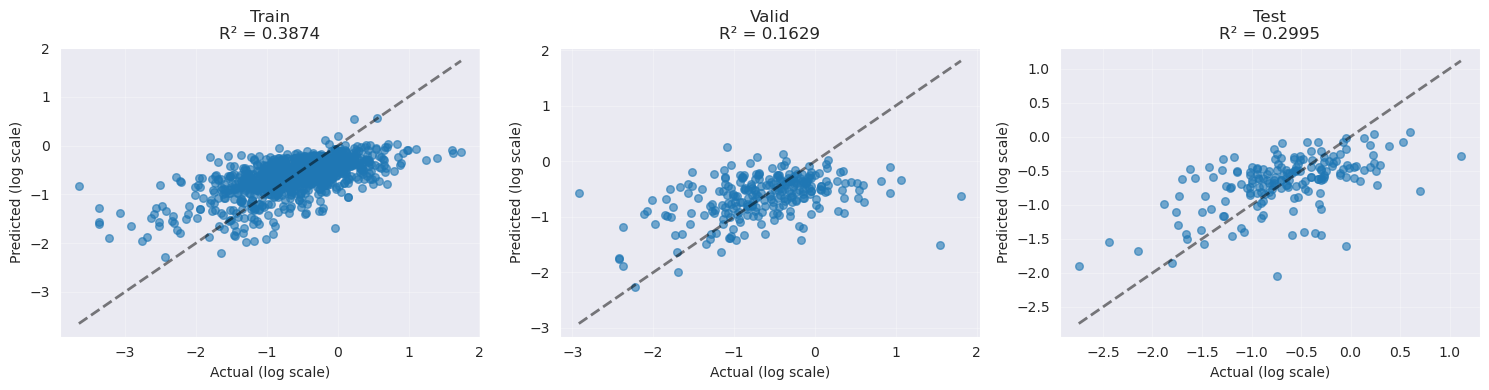

✓ Plot saved: ./outputs/lgCL/k5_f1/results/predictions_df_feature_5620_Thu_Apr__09_13-37-44_2026_38.png


In [20]:
# ============================================================================
# 6.1 Load Best Model
# ============================================================================

best_model_files = sorted([f for f in os.listdir(output_dirs['model_dir']) if f.endswith('.pt')])
model_file_for_export = None

if best_model_path and os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path))
    model_file_for_export = os.path.basename(best_model_path)
    print(f"✓ Loaded best model from current run: {model_file_for_export}")
elif best_model_files:
    fallback_model_path = os.path.join(output_dirs['model_dir'], best_model_files[-1])
    model.load_state_dict(torch.load(fallback_model_path))
    model_file_for_export = os.path.basename(fallback_model_path)
    print(f"✓ Loaded latest model from model_dir: {model_file_for_export}")
else:
    model_file_for_export = 'current_model.pt'
    print("⚠️  No checkpoint found, using current in-memory model")

model.eval()

# ============================================================================
# 6.2 Evaluate on all datasets
# ============================================================================

results_summary = {}
predictions_all = []

for dataset_name, dataset_df in [('Train', train_df), ('Valid', valid_df), ('Test', test_df)]:
    model.eval()
    all_preds = []
    all_actuals = []
    
    with torch.no_grad():
        for batch_start in range(0, len(dataset_df), TRAINING['batch_size']):
            batch_end = min(batch_start + TRAINING['batch_size'], len(dataset_df))
            batch_df = dataset_df.iloc[batch_start:batch_end]
            
            smiles_batch = batch_df['cano_smiles'].values
            y_batch = batch_df[TASK_NAME].values
            
            x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, _ = get_smiles_array(
                smiles_batch, feature_dicts
            )
            
            _, mol_pred = model(
                torch.Tensor(x_atom),
                torch.Tensor(x_bonds),
                torch.cuda.LongTensor(x_atom_index),
                torch.cuda.LongTensor(x_bond_index),
                torch.Tensor(x_mask)
            )
            
            all_preds.extend(mol_pred.cpu().numpy().flatten())
            all_actuals.extend(y_batch)
    
    y_true = np.array(all_actuals)
    y_pred = np.array(all_preds)
    
    # Compute metrics
    metrics = compute_metrics(y_true, y_pred, METRICS['threshold_fe'])
    results_summary[dataset_name] = metrics
    
    # Store predictions for saving
    preds_df = pd.DataFrame({
        'PUBCHEM_CID': dataset_df['PUBCHEM_CID'].values,
        'Actual': y_true,
        'Predicted': y_pred,
        'Dataset': f'{TASK_NAME}_{dataset_name.lower()}'
    })
    predictions_all.append(preds_df)
    
    print(f"\n{dataset_name} Set ({len(dataset_df)} samples):")
    print(f"  MAE:  {metrics['MAE']:.6f}")
    print(f"  RMSE: {metrics['RMSE']:.6f}")
    print(f"  R²:   {metrics['R2']:.6f}")
    print(f"  GMFE: {metrics['GMFE']:.4f}")

# ============================================================================
# 6.3 Save Results
# ============================================================================

metrics_stem = os.path.splitext(model_file_for_export)[0]

# Save metrics
metrics_df = pd.DataFrame(results_summary).T
metrics_path = os.path.join(output_dirs['result_dir'], f'metrics_{metrics_stem}.csv')
metrics_df.to_csv(metrics_path)
print(f"\n✓ Metrics saved: {metrics_path}")

# Save predictions
predictions_df = pd.concat(predictions_all, ignore_index=True)
predictions_path = os.path.join(output_dirs['result_dir'], f'results_{metrics_stem}.csv')
predictions_df.to_csv(predictions_path, index=False)
print(f"✓ Predictions saved: {predictions_path}")

# Plot predictions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (dataset_name, dataset_df) in enumerate([('Train', train_df), ('Valid', valid_df), ('Test', test_df)]):
    y_true = predictions_all[idx]['Actual'].values
    y_pred = predictions_all[idx]['Predicted'].values
    
    ax = axes[idx]
    ax.scatter(y_true, y_pred, alpha=0.6, s=30)
    
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, alpha=0.5)
    
    r2 = results_summary[dataset_name]['R2']
    ax.set_xlabel('Actual (log scale)')
    ax.set_ylabel('Predicted (log scale)')
    ax.set_title(f'{dataset_name}\nR² = {r2:.4f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(output_dirs['result_dir'], f'predictions_{metrics_stem}.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Plot saved: {plot_path}")

## Cell 7: Embedding Generation

In [ ]:
# ============================================================================
# 7.1 Modify Model for Embeddings
# ============================================================================

print("Generating embeddings...\n")

# Create a modified version that outputs embeddings
embedding_dim = 10
model_emb = Fingerprint(
    radius=MODEL['radius'],
    T=MODEL['T'],
    num_atom_features=num_atom_features,
    num_bond_features=num_bond_features,
    fingerprint_dim=MODEL['fingerprint_dim'],
    output_units_num=embedding_dim,
    p_dropout=MODEL['p_dropout']
)

# Copy weights from trained model
model_emb.load_state_dict(model.state_dict(), strict=False)
model_emb.cuda()
model_emb.eval()

print(f"✓ Embedding model created with output dim: {embedding_dim}")

# ============================================================================
# 7.2 Extract Embeddings for All Molecules
# ============================================================================

all_embeddings = []
all_ids = []

with torch.no_grad():
    for batch_start in range(0, len(df_remained), TRAINING['batch_size']):
        batch_end = min(batch_start + TRAINING['batch_size'], len(df_remained))
        batch_df = df_remained.iloc[batch_start:batch_end]
        
        smiles_batch = batch_df['cano_smiles'].values
        
        x_atom, x_bonds, x_atom_index, x_bond_index, x_mask, _ = get_smiles_array(
            smiles_batch, feature_dicts
        )
        
        embeddings, _ = model_emb(
            torch.Tensor(x_atom),
            torch.Tensor(x_bonds),
            torch.cuda.LongTensor(x_atom_index),
            torch.cuda.LongTensor(x_bond_index),
            torch.Tensor(x_mask)
        )
        
        all_embeddings.extend(embeddings.cpu().numpy())
        all_ids.extend(batch_df['PUBCHEM_CID'].values)

# ============================================================================
# 7.3 Save Embeddings
# ============================================================================

embeddings_array = np.array(all_embeddings)
column_names = [f'{TASK_NAME}_{i+1}' for i in range(embedding_dim)]

embeddings_df = pd.DataFrame(embeddings_array, columns=column_names)
embeddings_df.insert(0, 'PUBCHEM_CID', all_ids)

emb_path = os.path.join(output_dirs['emb_dir'], f'{TASK_NAME.replace("lg", "")}_embs_{embedding_dim}.csv')
embeddings_df.to_csv(emb_path, index=False)

print(f"✓ Embeddings saved: {emb_path}")
print(f"  Shape: {embeddings_df.shape}")
print(f"\n First few rows:")
print(embeddings_df.head())

## Summary

✅ **Workflow Complete**

### Outputs
- **Models**: `lgCL/cv_5_fold/fold_1/saved_lgCL_mods/*.pt`
- **Metrics**: `lgCL/cv_5_fold/fold_1/results/metrics_*.csv`
- **Predictions**: `lgCL/cv_5_fold/fold_1/results/results_*.csv`
- **Plots**: `lgCL/cv_5_fold/fold_1/results/predictions_*.png`
- **Embeddings**: `lgCL/cv_5_fold/fold_1/embeddings/CL_embs_*.csv`

### To re-run for different settings:
1. Edit `config.py` (parameters, fold_id, etc.)
2. Re-run cells 1-7 in order

### To extend this workflow:
- Add more folds by changing `TRAINING['fold_id']`
- Adjust hyperparameters in `config.py`
- Modify `utils.py` for custom metrics or plotting